#<font color="darkred">***THE DEFENSE OF WESTEROS***</font>

The winter is coming, and the Night's Watch is preparing their defense against the more than possible attack from the White Walkers, a one hundred thousand man army that lurks in the darkness.
To prevent it, Lord Commander has entrasted us with analyzing images that our ravens get from beyond the wall. The goal is to analyze these images to find and detect enemies and possible threats by implementing histograms, look-up-tables and different techniques for image processing that we are going to explain further in this notebook.

<div align="center">
  <img src='https://lossietereinos.com/wp-content/uploads/2012/10/El-Muro.png' width="500" height="300">
</div>

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # If your notebook and images are in your Drive, change directory accordingly:
    %cd '/content/drive/Othercomputers/Mi portátil/cuadernos_extra'
except ImportError:
    pass

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib
from ipywidgets import interactive, fixed, widgets

images_path = './images/'

Mounted at /content/drive
/content/drive/Othercomputers/Mi portátil/cuadernos_extra


###<h2 align="center"><font color="#006400">***CHAPTER I: THE NIGHT AT WINTERFELL***</font></h2>

For this first part, we are going to inspect the images from our ravens and try to improve the global contrast in order to make our job easier. This will involve analyzing the pixel distribution through histograms to understand the current state of the image and then applying techniques to spread out these pixel intensities, enhancing visibility of critical details that might otherwise be hidden in the low-contrast blizzard conditions.

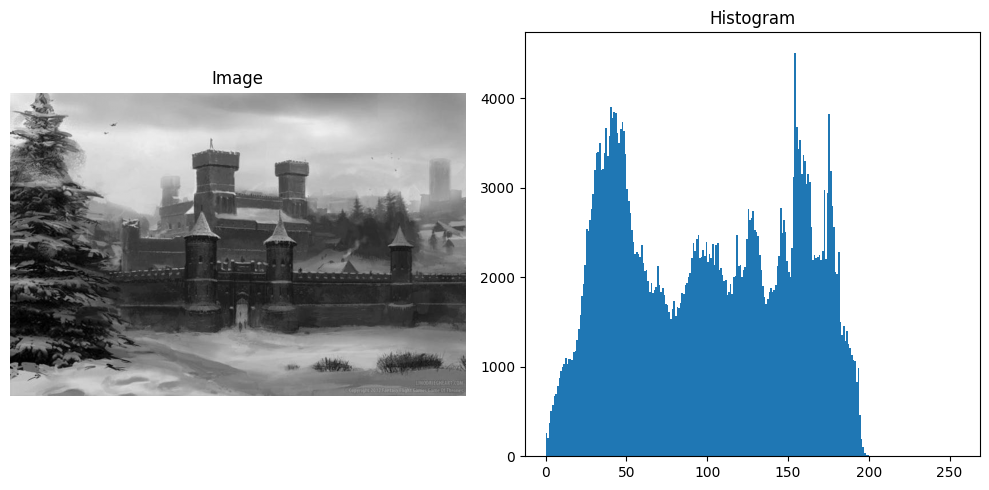

In [ ]:
image = cv2.imread(images_path + 'winterfell_blizzard.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5)) # Increased figure size
plt.subplots_adjust(wspace=0.3) # Add spacing between subplots

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image, cmap='gray')
plt.axis('off') # Hide axes for cleaner image display

# Now, show its histogram
plt.subplot(1,2,2)
plt.title("Histogram")
plt.hist(image.ravel(), 256, range=[0, 256])

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

By seeing the histogram of our picture, we can determine that the image has a big concentration of pixels between 0 and 200, but there are no pixels higher than 200. This indicates a low-contrast image, especially in the brighter regions, where details might be lost due to the compressed range of pixel intensities. To effectively identify threats and features in these challenging conditions, we need to enhance the contrast, which histogram equalization can help achieve by distributing the pixel values across the full dynamic range.

In [ ]:
def equalize_chart(image, verbose=False):
    """ Applies histogram equalization to an image and shows the result.

        Args:
            image: Input image
            verbose: Only show images if this is True

        Returns:
            out_image: Equalized histogram image
    """

    #Transform image to YCrCb color space
    image = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
    out_image = np.copy(image)

    # Apply histogram equalization to first band of the YCrCb image
    out_image[:,:,0] = cv2.equalizeHist(out_image[:,:,0])

    if verbose:

        # Plot histogram of gray image
        plt.subplot(2,2,3)
        plt.hist(image[:,:,0].ravel(),256,[0,256])
        plt.title('Original histogram')

        # Plot equalized histogram of the processed image
        plt.subplot(2,2,4)
        plt.hist(out_image[:,:,0].ravel(),256,[0,256])
        plt.title('Equalized histogram')

        # Reconvert image to RGB
        image = cv2.cvtColor(image, cv2.COLOR_YCrCb2RGB)
        out_image = cv2.cvtColor(out_image, cv2.COLOR_YCrCb2RGB)

        # Show the initial image
        plt.subplot(2,2,1)
        plt.imshow(image, cmap='gray')
        plt.title('Original image')

        # Show the resultant one
        plt.subplot(2,2,2)
        plt.imshow(out_image, cmap='gray')
        plt.title('Equalized histogram image')

    return out_image

In [15]:
# Read image
image = cv2.imread(images_path + 'batalla.jpg',-1)

# Equalize its histogram
interactive(equalize_chart, image=fixed(image), verbose=fixed(True))

interactive(children=(Output(),), _dom_classes=('widget-interact',))

¡Contemplad! Gracias al increíble poder de la ecualización del histograma, hemos logrado aumentar el contraste, revelando el ejército enemigo en toda su gloriosa oscuridad. ¡No más entrecerrar los ojos en la tormenta de nieve, Lord Comandante! Esos Caminantes Blancos creyeron que eran muy astutos, pero nuestra destreza en la manipulación de píxeles ha expuesto sus gélidas caras. Ahora sabemos exactamente quién viene a tomar el té (y a una batalla), y finalmente podemos distinguir si eso es un lobo huargo o solo un cúmulo de nieve muy esponjoso. ¡La victoria está prácticamente en el bolsillo!